In [116]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import pandas as pd

# import data

In [117]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()


In [118]:
data = pd.DataFrame(california.data, columns=california.feature_names)
data['MedHouseVal'] = california.target

In [119]:
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [120]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [121]:
data.shape

(20640, 9)

In [122]:
data.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

In [123]:
data.nunique()

MedInc         12928
HouseAge          52
AveRooms       19392
AveBedrms      14233
Population      3888
AveOccup       18841
Latitude         862
Longitude        844
MedHouseVal     3842
dtype: int64

In [124]:
data.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [125]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# EDA

In [126]:
cor=data.corr()
cor.shape

(9, 9)

<Axes: >

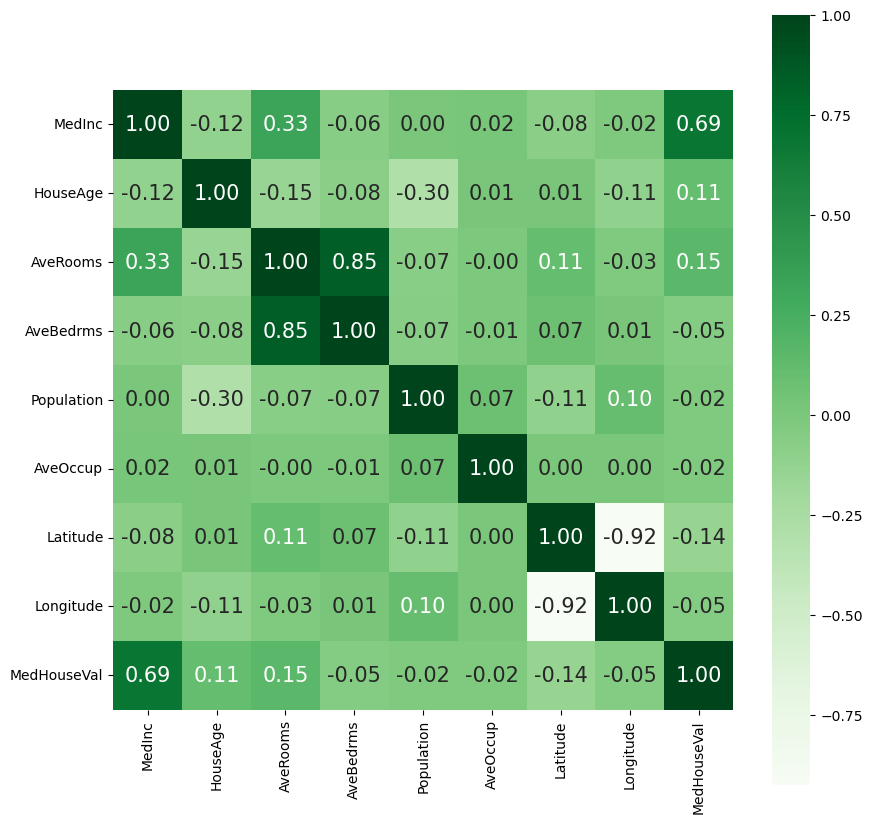

In [127]:
plt.figure(figsize=(10,10))
sns.heatmap(cor,square=True,fmt='.2f',annot=True,annot_kws={'size':15},cbar=True,cmap='Greens')

In [128]:
X=data[['MedInc']]
#X=data['AveBedrms'].values.reshape((-1,1))
Y=data['MedHouseVal']

In [129]:
Y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

## SPLIT FOR TRAIN

In [130]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size = 0.3, random_state = 4)

# StandardScaler

In [131]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 1 - simple regression

In [132]:
# Import library for Linear Regression
from sklearn.linear_model import LinearRegression

# Create a Linear regressor
slr = LinearRegression()

# Train the model using the training sets 
slr.fit(X_train, y_train)

LinearRegression()

In [133]:
slr.intercept_

2.0738813655869324

In [134]:
slr.coef_

array([0.79816839])

In [135]:
# Save feature names before scaling

feature_names = X.columns  # یا X_train_org.columns اگر اسم جدا دادی

# Build DataFrame of coefficients
coeffcients = pd.DataFrame({
    'Attribute': feature_names,
    'Coefficients': slr.coef_
})
coeffcients


,Attribute,Coefficients
0,MedInc,0.798168


In [136]:
from sklearn import metrics
y_pred = slr.predict(X_train)

### evaluate

In [137]:
print('R^2:',metrics.r2_score(y_train, y_pred))
print('MAE:',metrics.mean_absolute_error(y_train, y_pred))
print('MSE:',metrics.mean_squared_error(y_train, y_pred))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_train, y_pred)))

R^2: 0.4746858522764794
MAE: 0.6283207799297094
MSE: 0.7050206811266954
RMSE: 0.8396550965287446


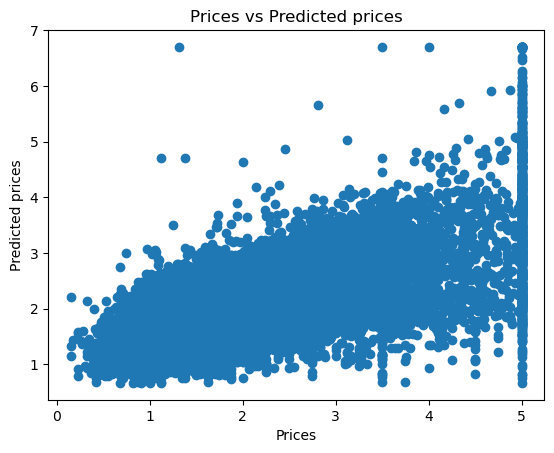

In [138]:
plt.scatter(y_train, y_pred)
plt.xlabel("Prices")
plt.ylabel("Predicted prices")
plt.title("Prices vs Predicted prices")
plt.show()

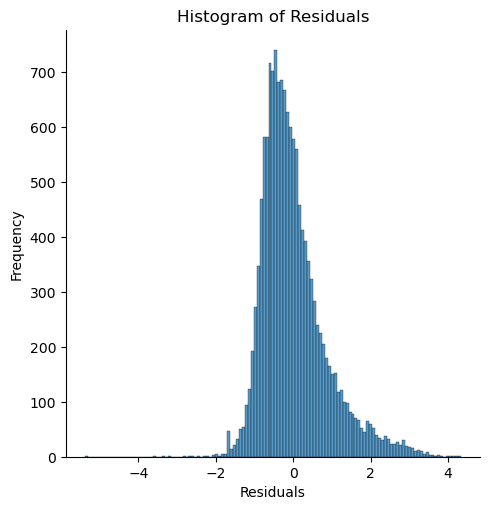

In [139]:
sns.displot(y_train-y_pred)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

## 2 - multiple regression

In [140]:
X=data.drop('MedHouseVal',axis=1)
Y=data['MedHouseVal']

In [141]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size = 0.3, random_state = 4)

In [142]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [143]:
# Import library for Linear Regression
from sklearn.linear_model import LinearRegression

# Create a Linear regressor
mlr = LinearRegression()

# Train the model using the training sets 
mlr.fit(X_train, y_train)# Import library for Linear Regression
from sklearn.linear_model import LinearRegression

# Create a Linear regressor
mlr = LinearRegression()

# Train the model using the training sets 
mlr.fit(X_train, y_train)

LinearRegression()

In [144]:
mlr.intercept_

2.0738813655869395

In [145]:
mlr.coef_

array([ 0.8403077 ,  0.113649  , -0.26604423,  0.29627845, -0.0091377 ,
       -0.0456944 , -0.8985422 , -0.86965133])

In [146]:
# Save feature names before scaling
# Zakhire esme feature ha ghabl az scale kardan
feature_names = X.columns  # یا X_train_org.columns اگر اسم جدا دادی

# Build DataFrame of coefficients
# Sakhte DataFrame baraye namayesh zarayeb regression
coeffcients = pd.DataFrame({
    'Attribute': feature_names,
    'Coefficients': mlr.coef_
})
coeffcients


,Attribute,Coefficients
0,MedInc,0.840308
1,HouseAge,0.113649
2,AveRooms,-0.266044
3,AveBedrms,0.296278
4,Population,-0.009138
5,AveOccup,-0.045694
6,Latitude,-0.898542
7,Longitude,-0.869651


In [147]:
y_pred = mlr.predict(X_train)

In [148]:
print('R^2:',metrics.r2_score(y_train, y_pred))
print('MAE:',metrics.mean_absolute_error(y_train, y_pred))
print('MSE:',metrics.mean_squared_error(y_train, y_pred))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_train, y_pred)))

R^2: 0.6081901093734017
MAE: 0.5319076620403794
MSE: 0.5258454910434389
RMSE: 0.7251520468449627


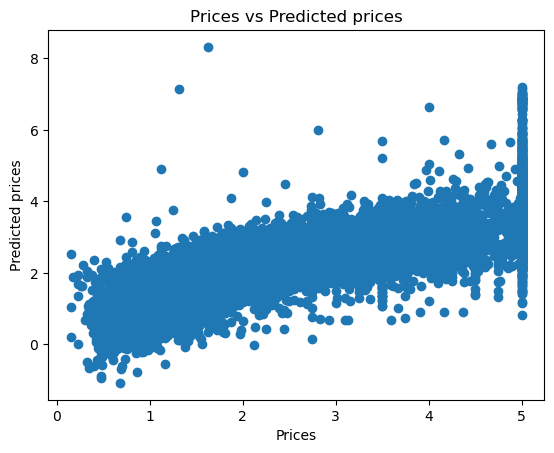

In [149]:
plt.scatter(y_train, y_pred)
plt.xlabel("Prices")
plt.ylabel("Predicted prices")
plt.title("Prices vs Predicted prices")
plt.show()

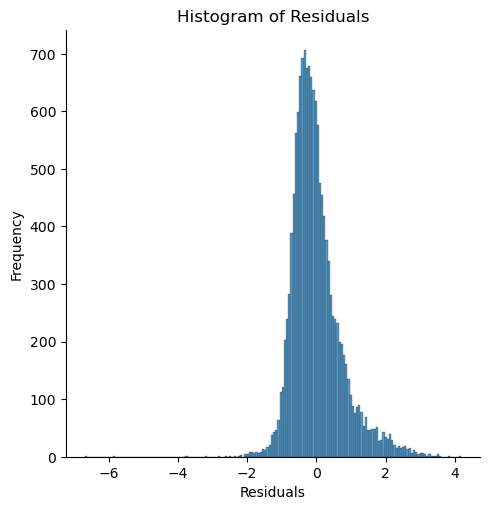

In [150]:
sns.displot(y_train-y_pred)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# 3 - Polynomial

In [151]:
from sklearn.preprocessing import PolynomialFeatures

In [152]:
poly_features = PolynomialFeatures(degree=2)
X_train_quadratic=poly_features.fit_transform(X_train)
lr=LinearRegression()
lr.fit(X_train_quadratic,y_train)
y_train_predicted=lr.predict(X_train_quadratic)
y_test_predicted=lr.predict(poly_features.fit_transform(X_test))

In [153]:
metrics.r2_score(y_train, y_train_predicted)

0.6970554355139266

In [154]:
metrics.r2_score(y_test, y_test_predicted)

0.47999149214932146

In [155]:
from sklearn.preprocessing import PolynomialFeatures
Poly_feature=PolynomialFeatures(degree=3)
X_train_quadratic_2=poly_features.fit_transform(X_train)
lr_=LinearRegression()
lr.fit(X_train_quadratic_2,y_train)
y_train_pred=lr.predict(X_train_quadratic_2)
y_test_pred=lr.predict(poly_features.fit_transform(X_test))

In [156]:
metrics.r2_score(y_train,y_train_pred)

0.6970554355139266

In [157]:
metrics.r2_score(y_test, y_test_pred)

0.47999149214932146